# CSCI E-25 
## Optical Flow   
### Steve Elston

In this assignment you will perform a exercises concerning optical flow. Code is provided and you are to answer the questions in the exercises. 

 These exercises are derived from an [example in the Scikit Image User Guide](https://scikit-image.org/docs/stable/auto_examples/registration/plot_opticalflow.html).

> Note: Before you proceed you may need to update the version of scikit-image and the Pooch package. To do so, uncomment and execute the code in the cell below. Then shut down your Jupyter server and restart.   

In [1]:
# !pip install --upgrade scikit-image
# !pip install pooch

To get started, execute the code in the cell below to import the packages you will need for this notebook.    

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.color import rgb2gray
from skimage.data import stereo_motorcycle, vortex
from skimage.transform import warp
from skimage.registration import optical_flow_tvl1, optical_flow_ilk
from itertools import product

## Iterative Lucas-Kanade (iLK) Algorithm

As a first simple example, you will apply the **iterative Lucas-Kanade** algorithm to a random field image. The random field image is generated by computing random pixel values. A second image is created by rotating the first around an axis in the image field. The goal is to register these two images and compute and display the optical flow field.   

Now, execute the code in the cell below to load and display the two images.

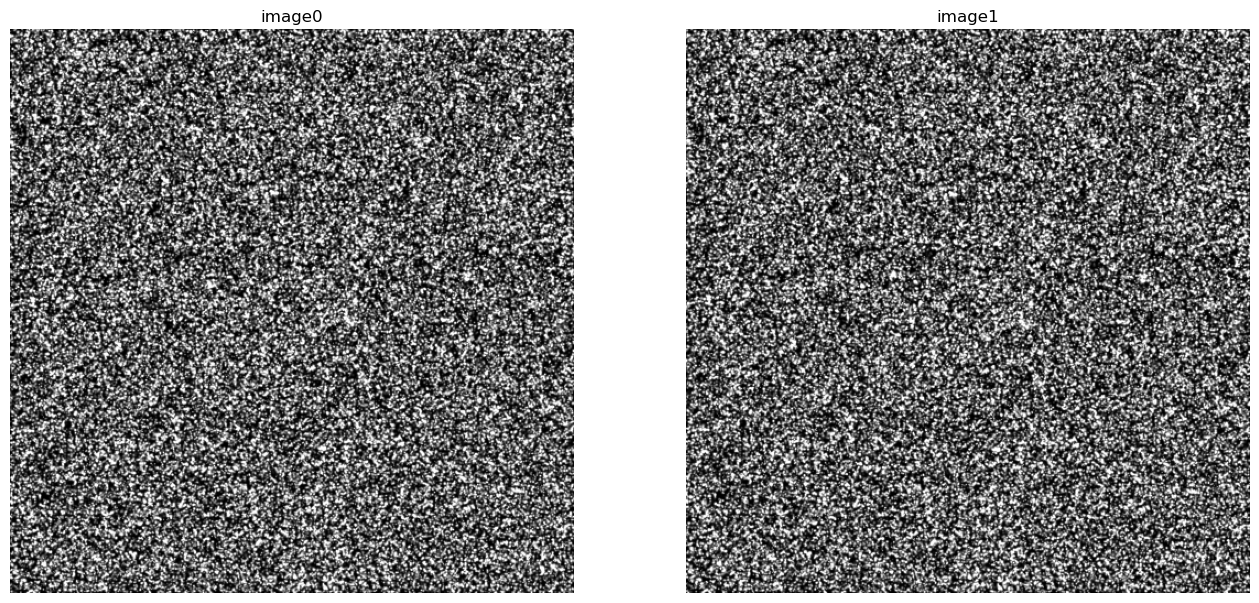

In [3]:
def plot_grayscale(img, h=8, ax=None, title = ''):
    if(ax==None): fig, ax = plt.subplots(1,1, figsize=(h, h))
    _=ax.imshow(img, cmap=plt.get_cmap('gray'))
    _=ax.set_title(title)
    _=ax.axis('off');


image0, image1 = vortex()

fig, ax = plt.subplots(1,2, figsize=(16,8))
plot_grayscale(image0, ax=ax[0], title='image0')
plot_grayscale(image1, ax=ax[1], title='image1')

> 🚩❓ **Exercise 12-1:** The iLK algorithm uses no smoothness constraint for regularization, imposing only the constant flow constraint. In a sentence of two, explain why for rough (random field) image the ikL algorithm with no smoothness constraint is a good choice. Or in other word, 

> ✅ **Answer:** iLK Algorithm with no smoothness constraint is a good choice for a rough (random field) image, because the small random field patches have enough texture differences to detect the motion. On the other hand in cases of smooth surface (or lack of intensity gradients), the smoothness constraint, assuming that neighbouring pixels have a similar flow, can actually help detecting the flow.

You will now compute the optical flow components using iLK algorithm provided by [skimage.registration.optical_flow_ilk](https://scikit-image.org/docs/stable/api/skimage.registration.html#skimage.registration.optical_flow_ilk). The code in the cell below does the follow operations:  

1. Compute the horizontal and vertical optical flow between the two images. 
2. Compute the Euclidean norm of the flow field. 
3. Plot the results.

Execute this code and examine the results. 

(0.0, 1.0, 0.0, 1.0)

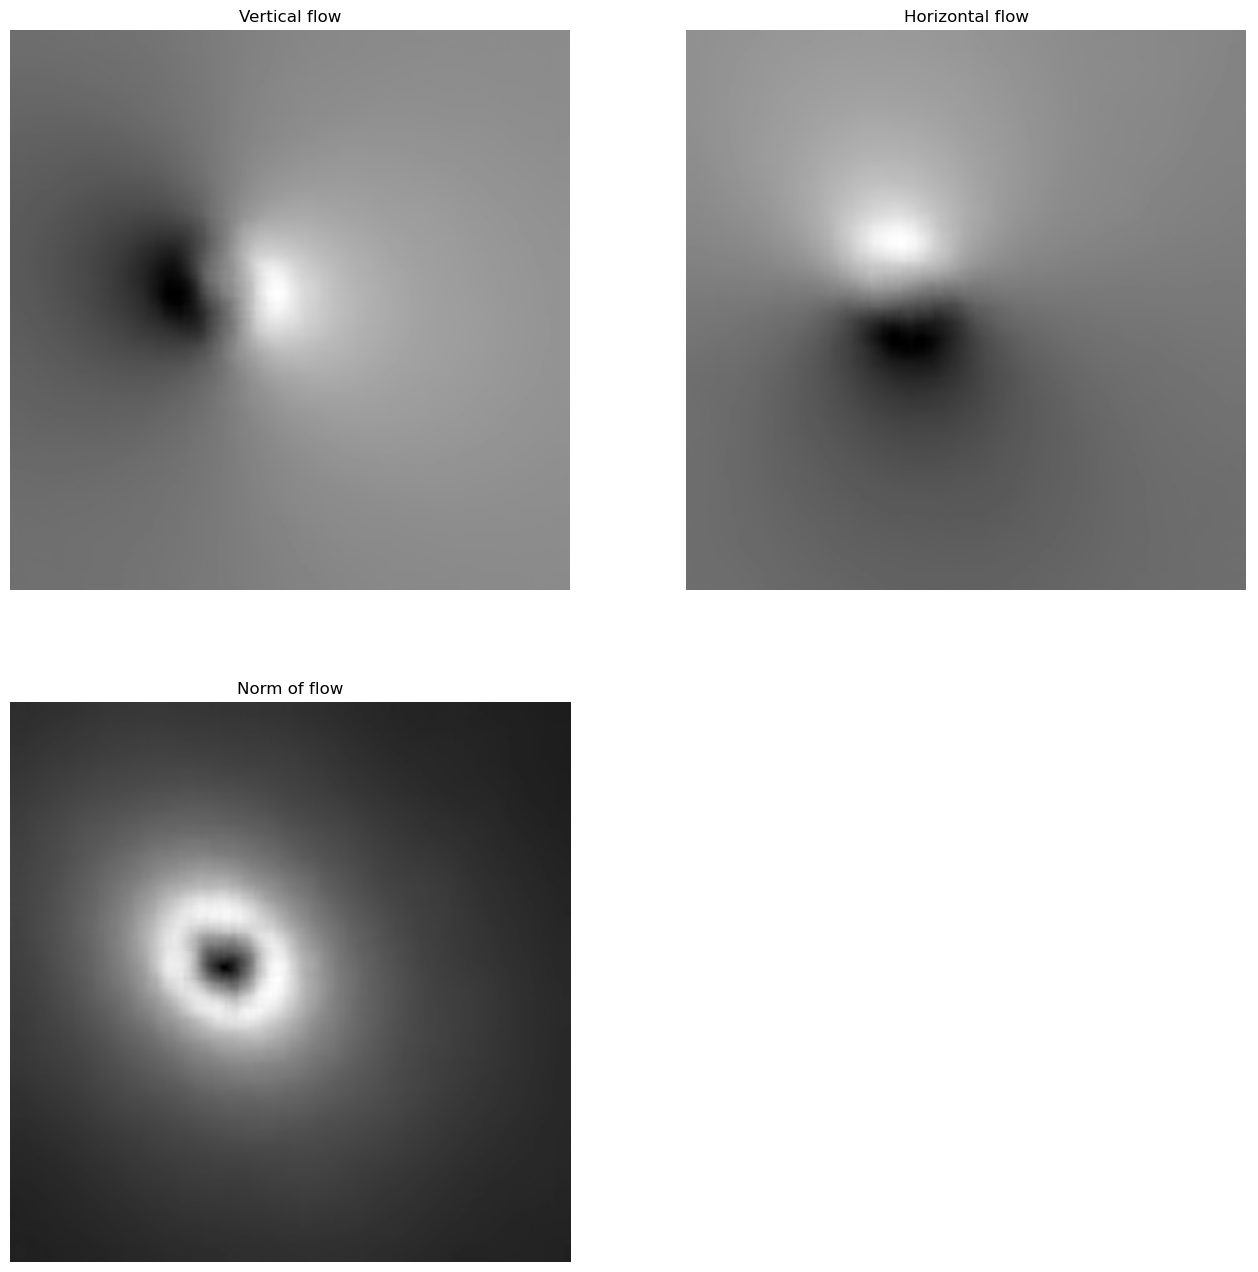

In [4]:
# Compute the optical flow
v, u = optical_flow_ilk(image0, image1, radius=15)
# Compute flow magnitude
norm = np.sqrt(u ** 2 + v ** 2)

fig, ax = plt.subplots(2,2, figsize=(16,16))
plot_grayscale(v, ax=ax[0,0], title='Vertical flow')
plot_grayscale(u, ax=ax[0,1], title='Horizontal flow')
plot_grayscale(norm, ax=ax[1,0], title='Norm of flow')
ax[1,1].axis('off')

With the flow field computed, it is instructive to display the examine the vector flow field. The code in the cell below does just this using the quiver plot function [matplotlib.pyplot.quiver](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html). Execute this code and examine the result.   

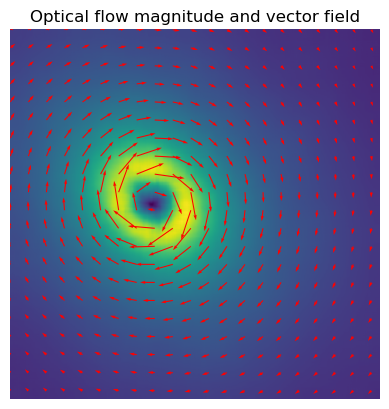

In [5]:
# Quiver plot arguments
nvec = 20  # Number of vectors to be displayed along each image dimension
nl, nc = image0.shape
step = max(nl//nvec, nc//nvec)

y, x = np.mgrid[:nl:step, :nc:step]
u_ = u[::step, ::step]
v_ = v[::step, ::step]

plt.imshow(norm)
plt.quiver(x, y, u_, v_, color='r', units='dots',
           angles='xy', scale_units='xy', lw=3)
plt.title("Optical flow magnitude and vector field")
plt.axis('off')

plt.show()

> 🚩❓ **Exercise 12-2:** Examine the plots of the horizontal flow, vertical flow, Euclidean norm of flow and the quiver plot of the flow field. Keep in mind that for the gray-scale images of flow a bright (light) value is strongly positive and a dark value is strongly negative. In a few sentences, answer the following questions.     
> 1. How does the flow field change as you move away from the axis of rotation?  
> 2. Are the different figures showing the flow field consistent and why? Hint; compare the vector flow to the images of horizontal and vertical flow as well as the norm of the flow. 

> ✅ **Answers:** 
> 1. The magnitude exhibits circular symmetry around the rotation axis. It initially increases from zero, reaching a maximum at a certain radial distance from the center, and then gradually decreases as the circle expands, stabilizing near zero at approximately half the image diagonal away from the rotation center.
> 2. The flow field figures are consistent. Since the flow is circular and symmetric around the "vortex" center, the first two plots are essentially identical, displaying the x and y components as orthogonal rotations of each other. I assume they correspond to the sine and cosine components of the same magnitude for flow vectors located along the concentric circles relatively to the rotation origin. Together, they form a perfectly circular flow.

## TV-L1 Algorithm

You will now work with an improved version of the TV-L1 algorithm. Here you will examine the optical flow between two time-sequential images. This image data set comes with ground truth.   

Execute the code in the cell below to load the  

In [6]:
# Load the sequence of images and displacement
image0, image1, disp = stereo_motorcycle()

The code in the cell below displays the two images, along with the Euclidean norm of ground truth displacement. Execute this code and examine the results. 

(0.0, 1.0, 0.0, 1.0)

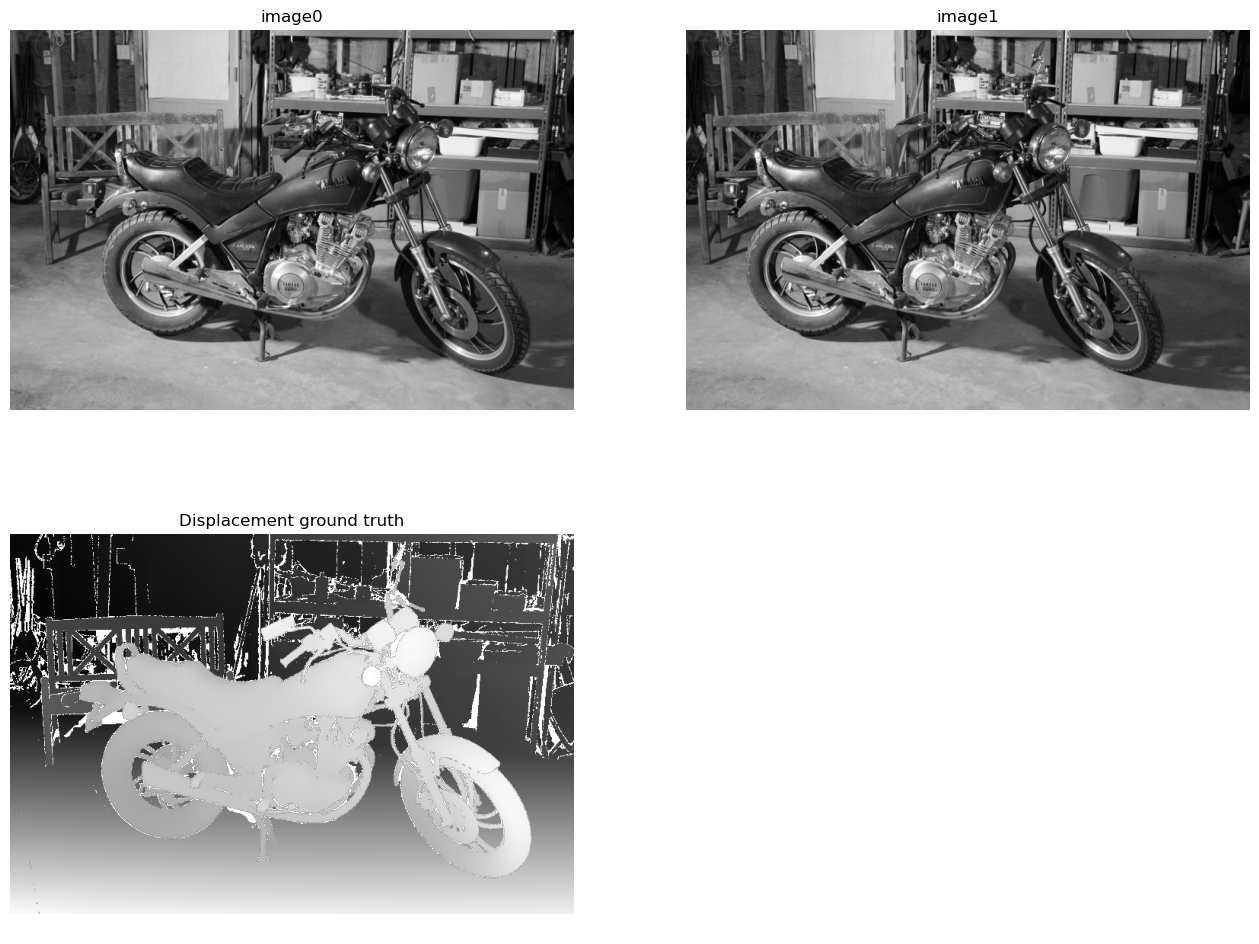

In [7]:
image0 = rgb2gray(image0)
image1 = rgb2gray(image1)

fig, ax = plt.subplots(2,2, figsize=(16,12))
plot_grayscale(image0, ax=ax[0,0], title='image0')
plot_grayscale(image1, ax=ax[0,1], title='image1')
plot_grayscale(disp, ax=ax[1,0], title='Displacement ground truth')  
ax[1,1].axis('off')

The lighter the pixel in the displacement image the greater the displacement. 

Another way to view the displacement between these images is by applying an optical trick. A 3-channel (RGB) image is created from the gray-scale images. The second (displaced) image is placed in the first channel. The first (reference) image is placed in the second and third channel. In this way, displacements can be seen as red-green shadows. Execute the code in the cell below and examine the result.  

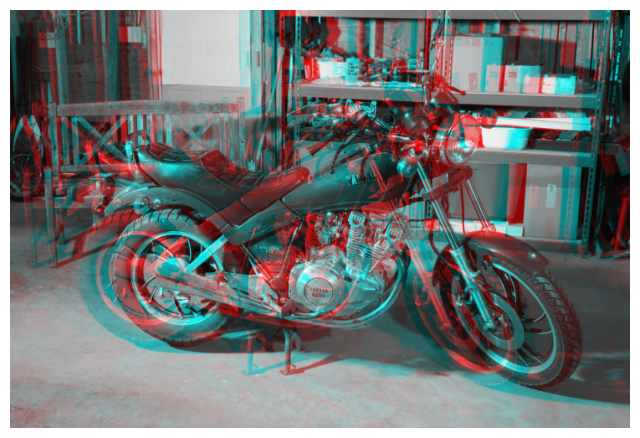

In [8]:
def DisplacementTORGB(image0, image1):
    nr,nc = image0.shape
    seq_im = np.zeros((nr, nc, 3))
    seq_im[..., 0] = image1
    seq_im[..., 1] = image0
    seq_im[..., 2] = image0
    return(seq_im)

plot_grayscale(DisplacementTORGB(image0, image1))

The code in the cell below performs the following operations:  
1. Computes the optical flow between the two images using the TV-L1 algorithm provided by the [skimage.registration.optical_flow_tvl1](https://scikit-image.org/docs/stable/api/skimage.registration.html#skimage.registration.optical_flow_tvl1) function. 
2. Computes norm of the flow field vectors. 
3. Computes the pixel-by-pixel end-point error, filter for infinite values (from zero divides), and print the average end-point error. 
4. Display the vertical flow field, horizontal flow field, Euclidean norm of the flow, displacement ground truth, and end-point error field. 

Execute the code and examine the results. 

Average end-point error = 6.4592657


(0.0, 1.0, 0.0, 1.0)

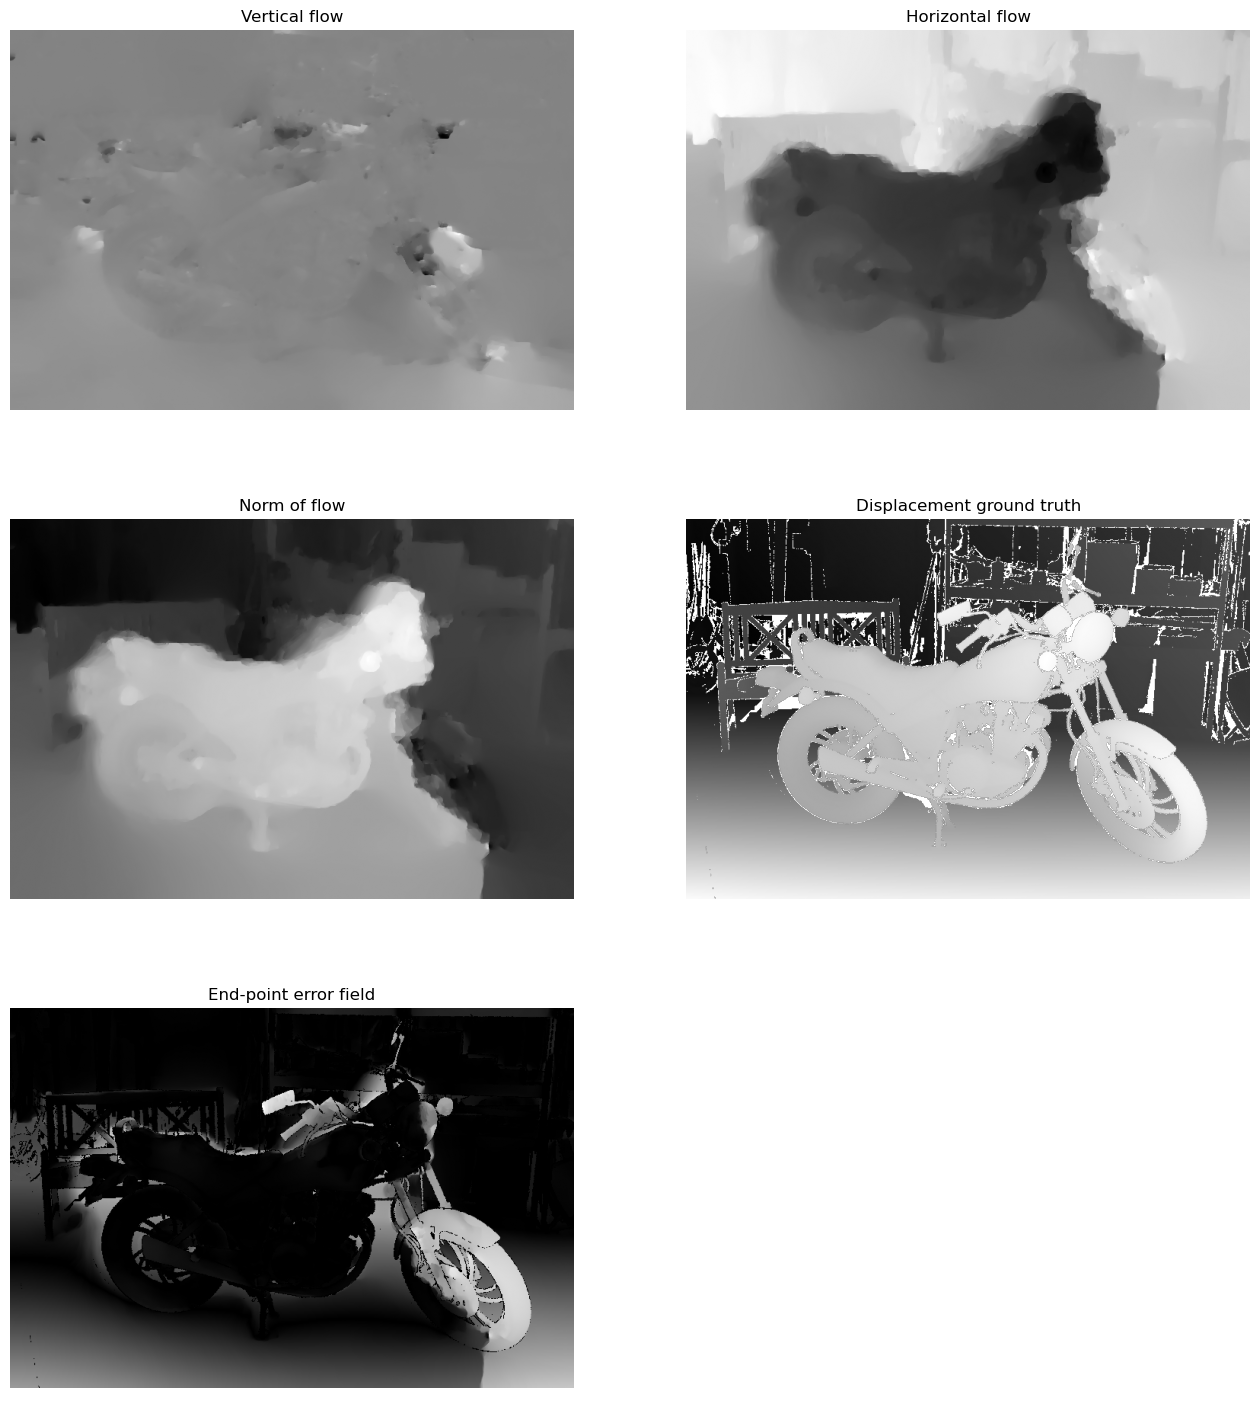

In [9]:
v, u = optical_flow_tvl1(image0, image1)
tvl1_15_vu = v, u

flow_norm = np.sqrt(u ** 2 + v ** 2)

endpoint_error = np.sqrt(np.square(flow_norm - disp))
endpoint_error[endpoint_error==np.Inf] = 0.0
print('Average end-point error = ' + str(np.mean(endpoint_error)))

fig, ax = plt.subplots(3,2, figsize=(16,18))
plot_grayscale(v, ax=ax[0,0], title='Vertical flow')
plot_grayscale(u, ax=ax[0,1], title='Horizontal flow')
plot_grayscale(flow_norm, ax=ax[1,0], title='Norm of flow')
plot_grayscale(disp, ax=ax[1,1], title='Displacement ground truth')  
plot_grayscale(endpoint_error, ax=ax[2,0], title='End-point error field')  
ax[2,1].axis('off')
ax[2,1].axis('off')

> 🚩❓ **Exercise 12-3:** Examine these results and answer the following questions in one or two sentences.  
> 1. This the estimated flow more vertical or horizontal, and how can you tell?  
> 2. What portion of the image exhibits the greatest error in the flow field and how can you tell.  

> ✅ **Answers:**
> 1. The estimated flow is primarily horizontal, as evident from the vertical and horizontal flow component diagrams. The vertical component is uniform, while the horizontal component shows a large dark region resembling the motorcycle against a gray background. The dark color indicates negative flow values, suggesting motion from right to left.
> 2. The right rearview mirror and the front wheel segment exhibit the greatest errors. This is evident in the "End-point Error Field" diagram, where these regions (particularly the motorcycle wheel and rearview mirror) appear bright white, indicating high error values.

Next, execute the code in the code to display the original image first image, the warped second image, and the registered image created with the first image warped second image.  

(0.0, 1.0, 0.0, 1.0)

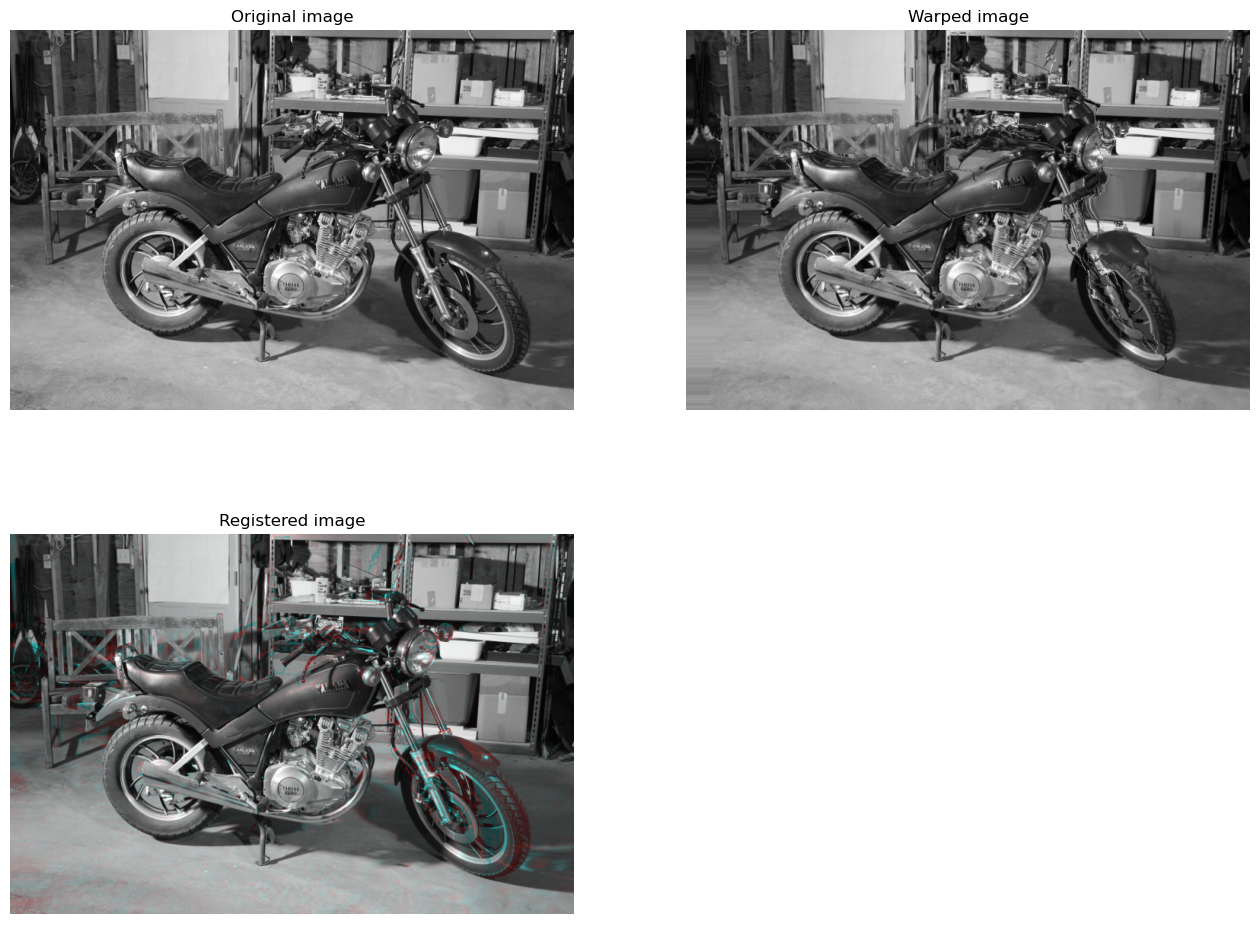

In [10]:
nr, nc = image0.shape
row_coords, col_coords = np.meshgrid(np.arange(nr), np.arange(nc), indexing='ij')
image1_warp = warp(image1, np.array([row_coords + v, col_coords + u]),mode='edge')

fig, ax = plt.subplots(2,2, figsize=(16,12))
plot_grayscale(DisplacementTORGB(image0, image0), ax=ax[0,0], title = 'Original image')
plot_grayscale(image1_warp, ax=ax[0,1], title = 'Warped image')
plot_grayscale(DisplacementTORGB(image0, image1_warp), ax=ax[1,0], title = 'Registered image')
ax[1,1].axis('off')

> 🚩❓ **Exercise 12-4:** Examine these results. Where are the largest registration errors and are these consistent with the flow errors you investigated in Exercise 12-3? 

> ✅ **Answers:** The largest errors are in the front wheel and right rearview mirror areas. This is consistent with the errors indicated on the "End-point eroor" diagram in the Exercise 12-3.

Next, you will repeat the steps of computing characteristics of the optical flow, but using the a larger parameter value, $\lambda$, 150, vs. the default value of 15 used in the first example. The larger parameter value favors brightness continuity. Execute the code and examine the results.  

Average end-point error = 5.4036055


(0.0, 1.0, 0.0, 1.0)

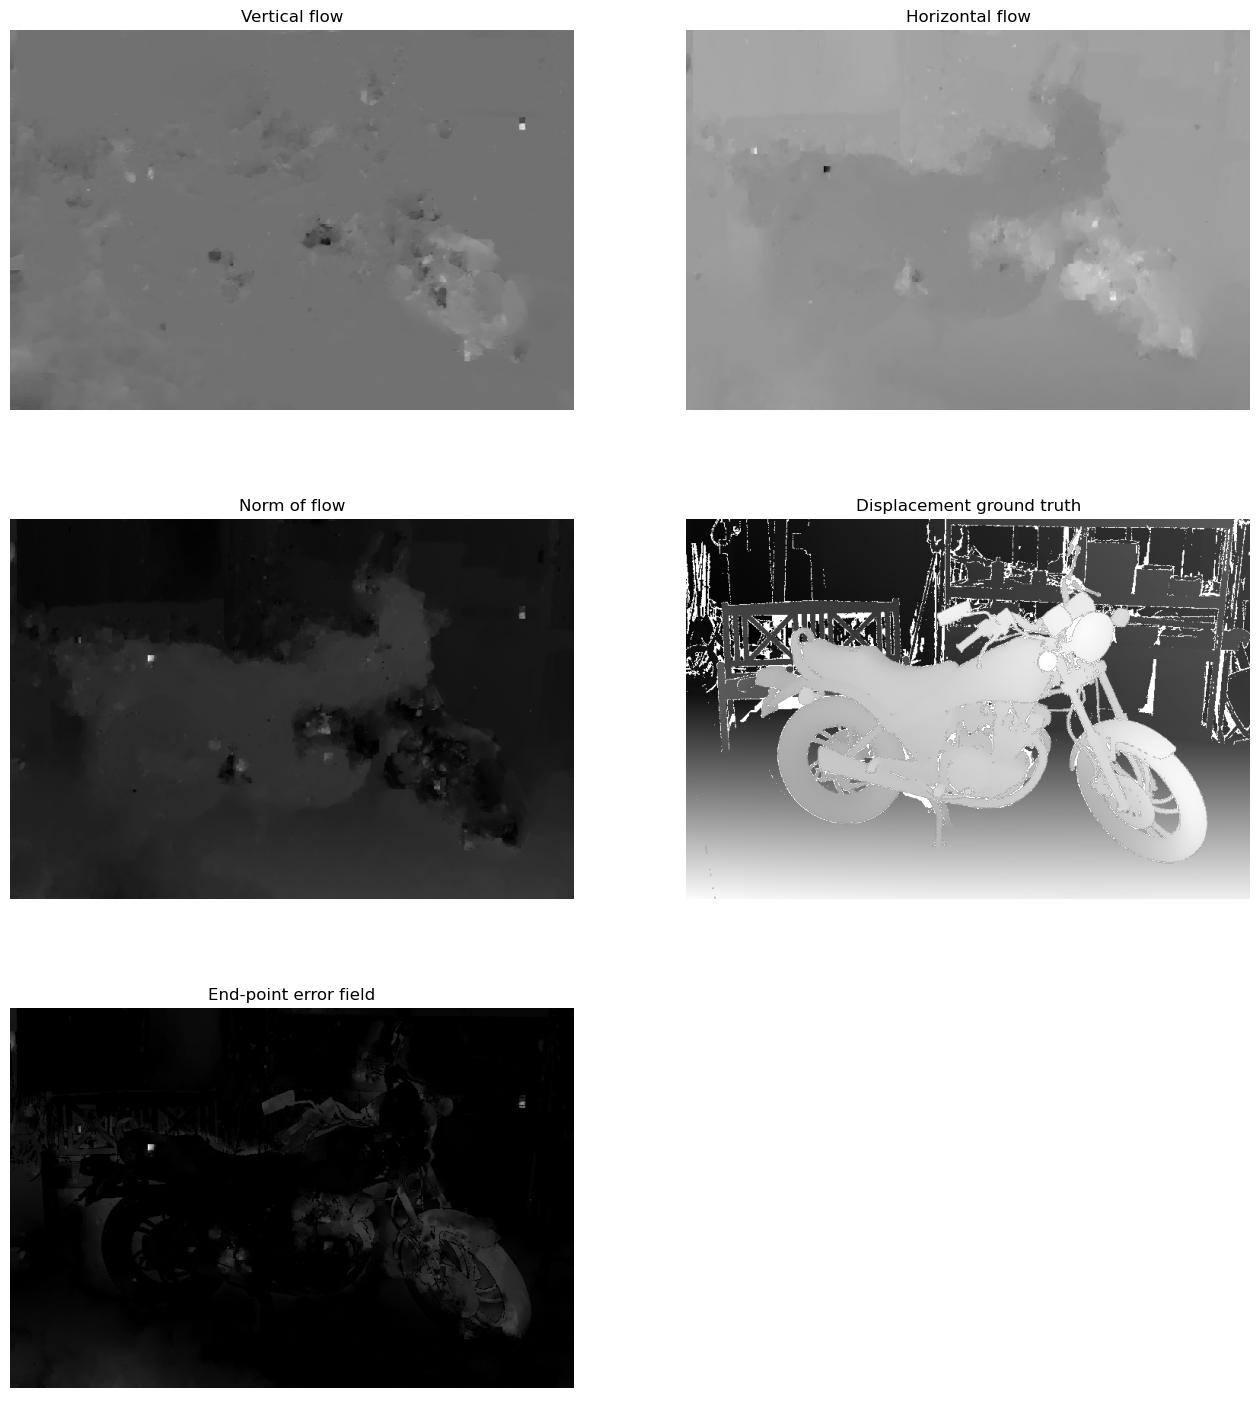

In [11]:
v, u = optical_flow_tvl1(image0, image1, attachment=150)
tvl1_150_vu = v, u

flow_norm = np.sqrt(u**2 + v**2)

endpoint_error = np.sqrt(np.square(flow_norm - disp))
endpoint_error[endpoint_error==np.Inf] = 0.0
print('Average end-point error = ' + str(np.mean(endpoint_error)))

fig, ax = plt.subplots(3,2, figsize=(16,18))
plot_grayscale(v, ax=ax[0,0], title='Vertical flow')
plot_grayscale(u, ax=ax[0,1], title='Horizontal flow')
plot_grayscale(flow_norm, ax=ax[1,0], title='Norm of flow')
plot_grayscale(disp, ax=ax[1,1], title='Displacement ground truth')  
plot_grayscale(endpoint_error, ax=ax[2,0], title='End-point error field')  
ax[2,1].axis('off')
ax[2,1].axis('off')

> 🚩❓ **Exercise 12-5:** Compare these results to the results with smaller value of $\lambda$ and answer the following these questions in one or two sentences.      
> 1. Comparing the average end-point errors, which value of $\lambda$ provides a better result?    
> 2. What differences can you see in the flow field images and is this expected given the value change in $\lambda$?    
> 3. What differences can you see in the end-point error fields between the two values of $\lambda$?    

> ✅ **Answers:**
> 1. Assuming we aim to minimize errors using the "Average End-Point Error" (AEPE) metric, the `attachment` value of 150 produces better results, yielding an AEPE of approximately 5.44 versus 6.45 for `attachment` = 15. However, when visually comparing the backward warps of the shifted images using the resulting flow fields, the flow from `attachment` = 15 introduces less distortion, and in this way, it actually performs better. This especially stands out around the steering wheel and engine areas, where the `attachment` = 150 result introduces more noise in those regions (see the comparison in the next cell output).
> 2. The flow field images for `attachment` = 150 exhibit a more uniform horizontal flow. The background shows reduced rightward motion, while the motorcycle region shows reduced leftward motion, suggesting more smoothed flow across the scene.
> 3. The End-Point Error field for `attachment` = 150 highlights the same error-prone regions as the `attachment` = 15 results, but these areas are less bright, indicating lower errors in those regions.


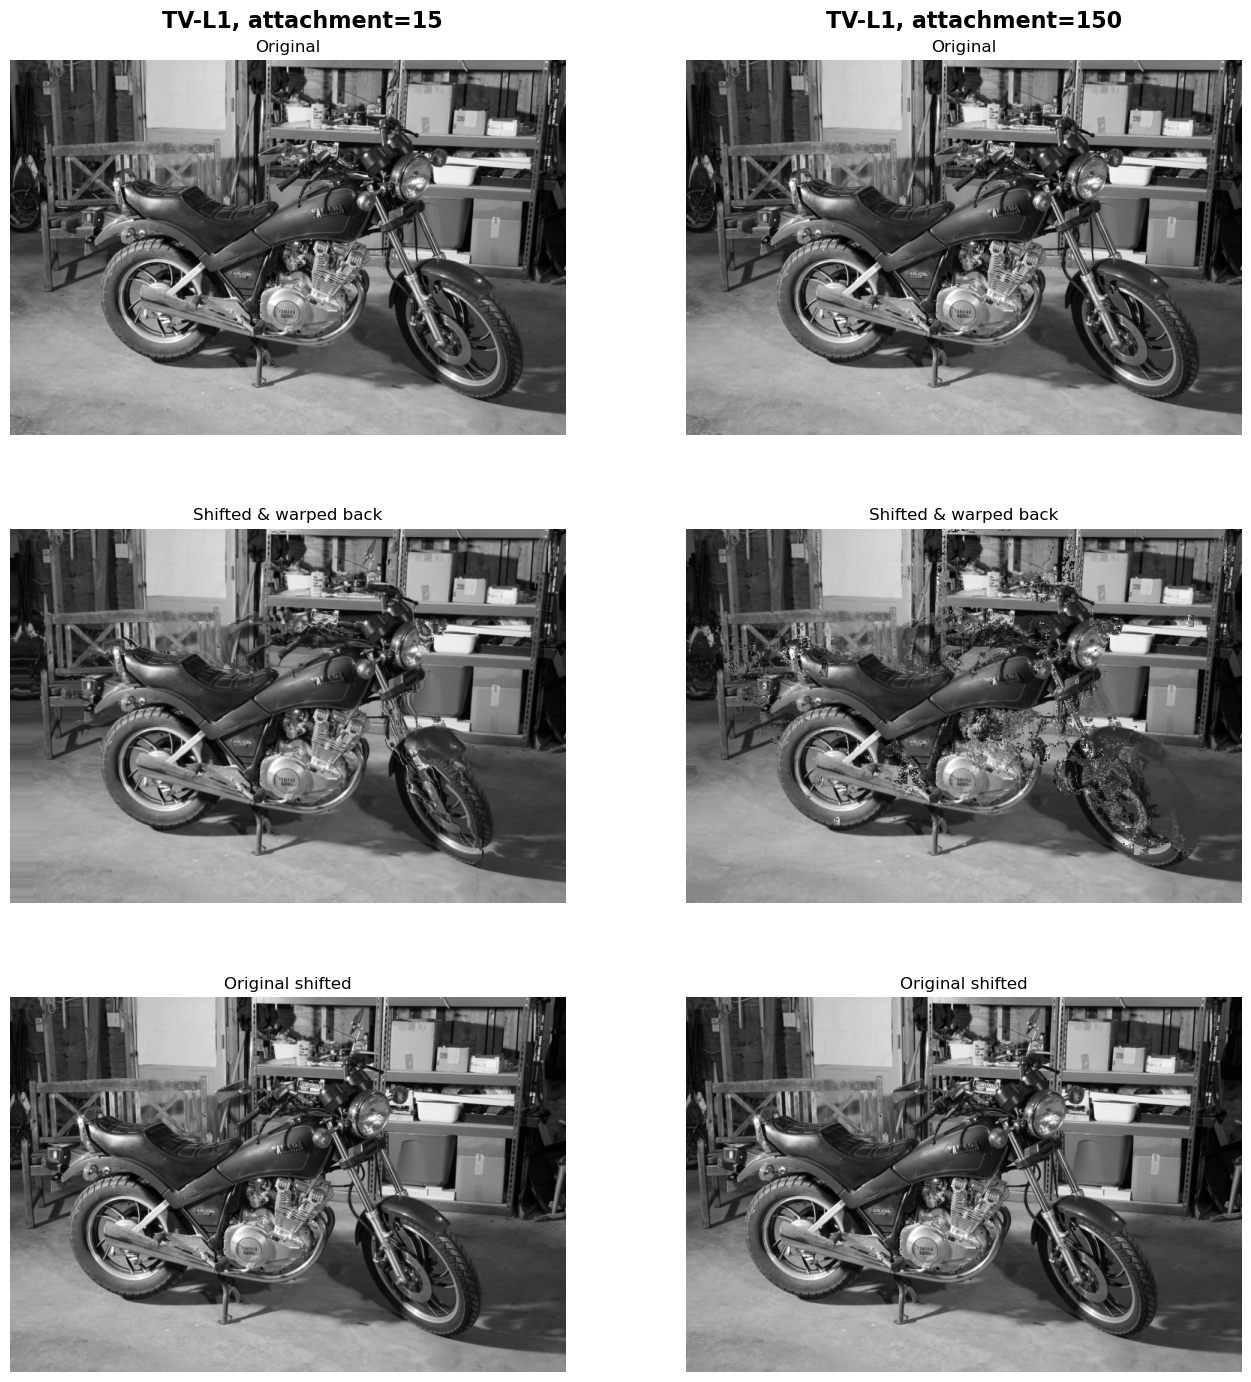

In [12]:
def two_flow_compare(flow0, flow1, image0, image1):
    nr, nc = image0.shape
    row_coords, col_coords = np.meshgrid(np.arange(nr), np.arange(nc), indexing='ij')

    # Warp back the shifted image using the flow vector field
    
    v, u = flow0
    image1_warp_flow0 = warp(image1, np.array([row_coords + v, col_coords + u]),mode='edge')
    
    v, u = flow1
    image1_warp_flow1 = warp(image1, np.array([row_coords + v, col_coords + u]),mode='edge')

    # Prepare the data for plotting
    
    flow0_data = [
        {'img': image0, 'txt': 'Original'},
        {'img': image1_warp_flow0, 'txt': 'Shifted & warped back'},
        {'img': image1, 'txt': 'Original shifted'},
    ]
    
    flow1_data = [
        {'img': image0, 'txt': 'Original'},
        {'img': image1_warp_flow1, 'txt': 'Shifted & warped back'},
        {'img': image1, 'txt': 'Original shifted'},
    ]

    flows = [*zip(flow0_data, flow1_data)]

    # Plot the original and warped images
    
    fig, ax = plt.subplots(3, 2, figsize=(16, 16))
    
    fig.subplots_adjust(top=0.93, hspace=0.25)  # ← try 0.25 or even 0.2
    fig.text(0.31, 0.95, 'TV-L1, attachment=15', ha='center', fontsize=16, fontweight='bold')
    fig.text(0.73, 0.95, 'TV-L1, attachment=150', ha='center', fontsize=16, fontweight='bold')
    
    for i, j in product(range(3), range(2)):
        plot_grayscale(flows[i][j]['img'], ax=ax[i][j], title=flows[i][j]['txt'])

a = two_flow_compare(tvl1_15_vu, tvl1_150_vu, image0, image1)

Finally, execute the code in the code in the cell below to display the registration of the first image with the warped second image. 

(0.0, 1.0, 0.0, 1.0)

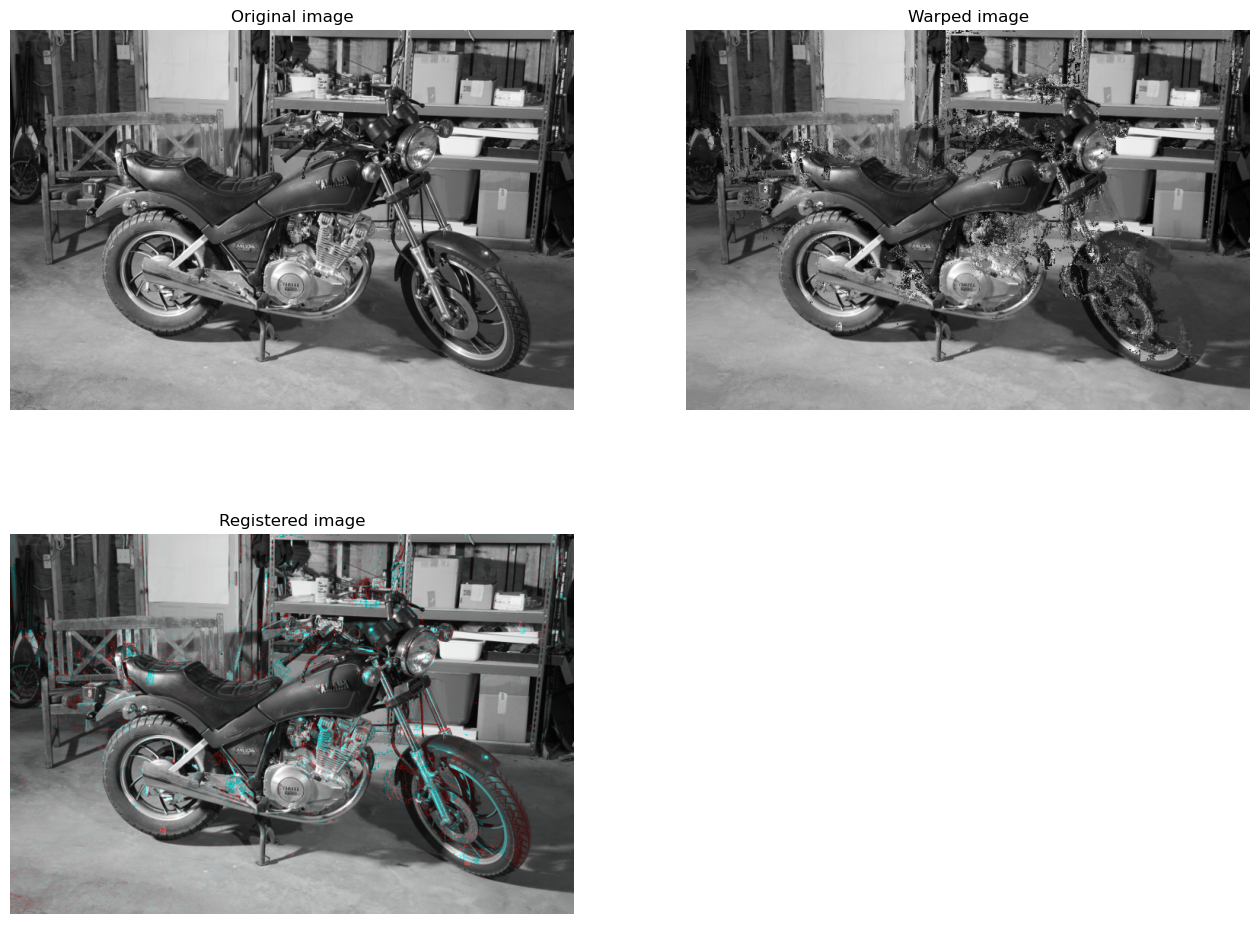

In [13]:
row_coords, col_coords = np.meshgrid(np.arange(nr), np.arange(nc), indexing='ij')
image1_warp = warp(image1, np.array([row_coords + v, col_coords + u]),mode='edge')

fig, ax = plt.subplots(2,2, figsize=(16,12))
plot_grayscale(DisplacementTORGB(image0, image0), ax=ax[0,0], title = 'Original image')
plot_grayscale(image1_warp, ax=ax[0,1], title = 'Warped image')
plot_grayscale(DisplacementTORGB(image0, image1_warp), ax=ax[1,0], title = 'Registered image')
ax[1,1].axis('off')

These results are not particularly different from the first set. This is expected from the minimal change in average end-point error. While not great, you should be able to see that the error is in fact a bit less around the front wheel of the motorcycle. 

> 🚩❓ **Exercise 12-6:** Scale is an important difficulty in computing optical flow fields. Answer the following questions in one or a few sentances.
> 1. Describe a real world situation where a large difference is scale occurs in a flow field.
> 2. What is a common approach to working with multiple scale in both conventional and neural flow field algorithms? What is the difference between the algorithm used in conventional and neural algorithms?
> 3. In one or a few sentances explain the roles of the two flow scales in the NeuFlow 2 algorithm and how the scales are used to compute the final flow field.

> ✅ **Answers:**
>
> 1. There can be many situations where large differences in scale occur within a flow field, such as:
>
>    * Autonomous vehicles, where the scene can range from close-up views to the distant horizon
>    * Video surveillance systems monitoring complex environments
>    * Wildlife observation and registration cameras, where animals may appear both very close and far away relative to the camera
>    * Robotic manipulators and onboard cameras of autonomous robots
>    * ... and many others
>
> 2. A common approach to handling multiple scales in both traditional and neural flow field algorithms is the use of pyramids. Traditional methods often use Laplacian pyramids, where flow is estimated at lower resolutions and then upsampled to reflect large-scale displacements in the final full-resolution flow field. Neural flow estimation algorithms use feature pyramids, applying similar principles through learned representations.
>
> 3. NeoFlow 2 uses two flow scales to balance computational efficiency and accuracy. The 1/16 flow captures large, uniform displacements, such as background motion or movement of large objects. It can also detect fast-moving objects that shift dramatically between frames, thanks to its large receptive field enabled by transformers. The 1/8 flow is used to upsample and refine the coarse 1/16 flow to a higher resolution. It also helps detect very small moving objects that might otherwise blur out, and captures non-uniform motion within a single object, such as deformation or rotation.


> 🚩❓ **Exercise 12-7:** Neural network optical flow algorithms often use a correlation volume. In one or a few sentances answer the following wuestions.    
> 1. Describe the nature and purpose of the corrlation volume data structure.   
> 2. How will low gradient areas affect the calculations requried for the correlation volume?    
> 3. How does the use of multi-scale flow help mitagate the affect of low gradient areas of the image?     

> ✅ **Answer:**
> 1. The correlation volume iteratively updates the flow field for each pixel based on the similarity between its 1/8-scale flow feature vector and those of neighboring pixels within a square window of size (K+1)×(K+1), centered on the target pixel. Matching is typically performed using dot product. The pixel's flow is updated by RNN refinement module using the corellation volume information to direct displacement, generally toward the neighbor with the highest similarity score. This process is repeated iteratively.
> 2. In low-gradient regions, the feature vectors become more uniform, making the selection of the highest-correlation neighbor more ambiguous.
> 3. Multi-scale flow helps mitigate the effects of low-gradient areas by providing global flow information to the refinement process, propagating it even to regions where the correlation volume don't really help.

#### Copyright 2022, 2024. 2025, Stephen F Elston. All rights reserved. 